# Modèles d'IA — Détection et Classification du Harcèlement en Ligne

Ce notebook présente les 5 modèles qu'on a entraînés pour détecter automatiquement si un message est haineux ou non, et si oui à quelle catégorie il appartient. On compare leurs performances pour savoir lequel est le plus efficace.

## 1. Préparation générale

**Ce qu'on cherche à faire :**
- Détecter si un message est haineux ou non *(tâche binaire)*
- Si haineux, trouver la catégorie parmi : Homophobie, Islamophobie, Racisme, Sexisme, Validisme, Xénophobie *(tâche multi-classes)*

**Les données :**
- `Base_Train2.csv` → 2400 messages pour entraîner les modèles (1200 haineux, 1200 neutres)
- `Base_Test2.csv` → 240 messages pour le test final — ces données ne sont jamais utilisées pendant l'entraînement

**Pourquoi ces deux bases séparées ?**
Pour mesurer les vraies performances du modèle sur des données inconnues. Si on testait sur les mêmes données qu'on a utilisées pour apprendre, les résultats seraient artificiellement bons.

**Pourquoi distinguer ces deux tâches ?**

La tâche **binaire** répond à : "Ce message est-il problématique ?"
→ Utile comme premier filtre automatique.

La tâche **multi-classes** répond à : "De quelle forme de haine s'agit-il ?"
→ Utile pour orienter la modération et comprendre quelles formes sont les
plus présentes. Un message islamophobe et un message sexiste ne demandent
pas forcément la même réponse.

Dans chaque section, on teste les deux niveaux : d'abord la détection
(haineux/non haineux), ensuite la classification fine (la catégorie).


**La cellule ci-dessous charge les deux bases de données et affiche les premières lignes pour vérifier que tout est bien chargé.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Chargement
train = pd.read_csv('/content/Base_Train2.csv')
test  = pd.read_csv('/content/Base_Test2.csv')

print(f'Train : {train.shape[0]} lignes | Test : {test.shape[0]} lignes')
print(f'Colonnes : {train.columns.tolist()}')
train.head(3)

Train : 2400 lignes | Test : 240 lignes
Colonnes : ['Identifiant', 'Texte', 'Traduction', 'Types', 'Categories']


,Identifiant,Texte,Traduction,Types,Categories
0,1,Why is it that all gay people are repulsive?,Pourquoi tous les homosexuels sont-ils considé...,Haineux,Homophobie
1,2,Gay people are a c a n c e r.,Les homosexuels sont un cancer.,Haineux,Homophobie
2,3,Deaht to all gay people.,Mort à tous les homosexuels.,Haineux,Homophobie


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 2. Régression Logistique

**Pourquoi ce modèle ?**
Nos visualisations avaient montré que les messages haineux et neutres ont des vocabulaires très différents. Les nuages de mots révélaient des mots spécifiques à chaque classe — "disabled", "muslims", "gay" pour les haineux, "love", "tiktok", "beauty" pour les neutres. Cette séparation nette justifie un modèle linéaire.

Le modèle est combiné avec **TF-IDF** qui transforme chaque message en vecteur numérique. TF-IDF pondère les mots selon leur importance : un mot rare mais discriminant aura plus de poids qu'un mot banal présent partout.

**Ce qu'on fait ici :**
- 2.1 : détecter si un message est haineux ou non
- 2.2 : identifier la catégorie de harcèlement parmi les 6, avec validation croisée

In [2]:
# =========================================================
# PROJET ML — HARCELEMENT
# - 2.1 Régression logistique binaire
# - 2.2 Régression logistique multi-classe
# - Validation croisée
# - Test réel + export CSV
# =========================================================

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# =========================================================
# 1. CHARGEMENT DES DONNÉES
# =========================================================
TRAIN_PATH = "Base_Train2.csv"
TEST_PATH  = "Base_Test2.csv"

def read_csv_safely(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Fichier introuvable: {path}")
    try:
        return pd.read_csv(path)
    except:
        return pd.read_csv(path, encoding="latin-1")

train_df = read_csv_safely(TRAIN_PATH)
test_df  = read_csv_safely(TEST_PATH)

train_df.columns = train_df.columns.str.strip()
test_df.columns  = test_df.columns.str.strip()

TEXT_COL = "Texte"

print("Colonnes :", train_df.columns.tolist())

# =========================================================
# 2. ===== 2.1 RÉGRESSION LOGISTIQUE BINAIRE =====
# =========================================================
print("\n" + "="*60)
print("2.1 RÉGRESSION LOGISTIQUE BINAIRE")
print("="*60)

train_bin = train_df.dropna(subset=[TEXT_COL, "Types"]).copy()
test_bin  = test_df.dropna(subset=[TEXT_COL, "Types"]).copy()

X_train_bin = train_bin[TEXT_COL].astype(str)
y_train_bin = train_bin["Types"]

X_test_bin = test_bin[TEXT_COL].astype(str)
y_test_bin = test_bin["Types"]

model_bin = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), stop_words="english")),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

model_bin.fit(X_train_bin, y_train_bin)
y_pred_bin = model_bin.predict(X_test_bin)

print("\n--- RÉSULTATS BINAIRE (TEST) ---")
print(classification_report(y_test_bin, y_pred_bin))

print("Matrice de confusion :")
print(confusion_matrix(y_test_bin, y_pred_bin))

# =========================================================
# 3. ===== 2.2 RÉGRESSION LOGISTIQUE MULTICLASSE =====
# =========================================================
print("\n" + "="*60)
print("2.2 RÉGRESSION LOGISTIQUE MULTICLASSE")
print("="*60)

train_cat = train_df.dropna(subset=[TEXT_COL, "Categories"]).copy()

X = train_cat[TEXT_COL].astype(str)
y = train_cat["Categories"]

# SPLIT 80/20
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"\nTrain: {len(X_train)} | Validation: {len(X_valid)}")

model_cat = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), stop_words="english")),
    ("clf", LogisticRegression(max_iter=3000))
])

# =========================================================
# 4. VALIDATION CROISÉE
# =========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nValidation croisée...")
cv_scores = cross_val_score(model_cat, X_train, y_train, cv=cv, scoring="f1_macro")
print("F1 moyen:", round(cv_scores.mean(),4))

# =========================================================
# 5. VALIDATION 20%
# =========================================================
model_cat.fit(X_train, y_train)
y_pred = model_cat.predict(X_valid)

print("\n--- RÉSULTATS VALIDATION 20% ---")
print(classification_report(y_valid, y_pred))

print("Matrice de confusion :")
print(confusion_matrix(y_valid, y_pred))

# =========================================================
# 6. TEST FINAL (BASE TEST)
# =========================================================
print("\n--- TEST FINAL (BASE_TEST2) ---")

test_cat = test_df.dropna(subset=[TEXT_COL, "Categories"]).copy()

y_test_cat = test_cat["Categories"]
X_test_cat = test_cat[TEXT_COL].astype(str)

y_pred_test = model_cat.predict(X_test_cat)

print(classification_report(y_test_cat, y_pred_test))

# =========================================================
# 7. EXPORT CSV
# =========================================================
model_cat.fit(X, y)

test_df["prediction"] = model_cat.predict(test_df[TEXT_COL].astype(str))

test_df.to_csv("predictions_test_final.csv", index=False, encoding="utf-8-sig")

print("\nFichier généré : predictions_test_final.csv")

import joblib
joblib.dump(model_bin, 'modele_reglog_binaire.pkl')
joblib.dump(model_cat, 'modele_reglog_multiclasse.pkl')
print("Modèles Régression Logistique sauvegardés.")

Colonnes : ['Identifiant', 'Texte', 'Traduction', 'Types', 'Categories']

2.1 RÉGRESSION LOGISTIQUE BINAIRE

--- RÉSULTATS BINAIRE (TEST) ---
              precision    recall  f1-score   support

     Haineux       0.93      0.84      0.88       120
 Non Haineux       0.85      0.93      0.89       120

    accuracy                           0.89       240
   macro avg       0.89      0.89      0.89       240
weighted avg       0.89      0.89      0.89       240

Matrice de confusion :
[[101  19]
 [  8 112]]

2.2 RÉGRESSION LOGISTIQUE MULTICLASSE

Train: 960 | Validation: 240

Validation croisée...
F1 moyen: 0.9028

--- RÉSULTATS VALIDATION 20% ---
              precision    recall  f1-score   support

  Homophobie       0.97      0.90      0.94        40
Islamophobie       0.86      0.90      0.88        40
     Racisme       0.97      0.90      0.94        40
     Sexisme       0.78      0.95      0.85        40
   Validisme       0.97      0.90      0.94        40
  Xénophobie     

### 2.1 Régression logistique binaire — Haineux / Non Haineux

On entraîne le modèle sur la base Train puis on l'évalue sur la base Test.

**Ce que fait le code ci-dessous :**
1. Charge les données Train et Test
2. Transforme les textes en vecteurs numériques avec TF-IDF
3. Entraîne la régression logistique
4. Affiche les performances sur la base Test avec un rapport de classification

**Lecture des résultats :**

Le rapport de classification affiche pour chaque classe :
- **Precision** : sur tous les messages classés "Haineux", combien l'étaient vraiment
- **Recall** : sur tous les vrais messages haineux, combien ont été détectés
- **F1-score** : moyenne entre precision et recall — la métrique principale

Une accuracy de 89% signifie que 89% des messages sont bien classés sur la base Test.
La matrice de confusion montre les erreurs : les faux négatifs (messages haineux classés neutres) sont les plus problématiques car ce sont des messages haineux qui passent inaperçus.

### 2.2 Régression logistique multi-classes — Les 6 catégories

On identifie maintenant quelle forme de harcèlement contient le message.
On utilise une **validation croisée à 5 folds** : le Train est découpé en 5 parties, on entraîne sur 4 et on teste sur la 5ème, répété 5 fois. La moyenne des scores donne une mesure fiable sans toucher à la base Test.

**Lecture des résultats :**

- Validation croisée sur Train : F1 moyen = **0.90**
- Validation 20% : Accuracy = **91%**, F1 = 0.91
- Test final sur Base Test : Accuracy = **91%**, F1 = 0.91

Les performances sont stables sur les 3 évaluations — le modèle généralise bien et n'a pas juste mémorisé les données d'entraînement.

**Par catégorie :**
- Validisme (0.97) et Homophobie (0.95) sont les mieux détectées — vocabulaire très exclusif
- Racisme (0.78) est plus difficile car il partage du vocabulaire avec la Xénophobie — ce qu'on avait anticipé grâce aux nuages de mots de l'EDA

## 3. TF-IDF + Régression Logistique

**Pourquoi ce modèle ?**
Nos visualisations avaient montré que certains mots sont très discriminants selon la catégorie — "muslims" apparaît massivement en Islamophobie, "disabled" en Validisme, "immigrants" en Xénophobie. TF-IDF exploite exactement ça : il donne plus de poids aux mots rares mais informatifs, et moins de poids aux mots banals présents partout.

Contrairement au Bag of Words qui compte juste les occurrences, TF-IDF pondère chaque mot selon sa fréquence dans le message ET sa rareté dans tout le corpus. Un mot très fréquent dans un seul message mais rare ailleurs reçoit un score élevé — c'est le signe qu'il est discriminant.

**Ce qu'on fait dans cette section :**
- Expérience 1 : entraînement sur Base_Train2, test sur Base_Test2 (données jamais vues)
- Expérience 2 : 3 entraînements avec découpages différents pour vérifier la stabilité des résultats

### Expérience 1 — Entraînement sur Base_Train2, test sur Base_Test2

Le modèle est entraîné sur 2400 messages puis testé sur 240 messages jamais vus. C'est la mesure la plus réaliste des performances réelles du système.

**Ce que fait le code ci-dessous :**
1. Transforme les textes en vecteurs TF-IDF (5000 mots max, unigrammes + bigrammes)
2. Entraîne un modèle binaire (Haineux / Non Haineux) sur le Train
3. Entraîne un modèle multi-classes (les 6 catégories) sur le Train
4. Teste les deux modèles sur la Base Test
5. Exporte les prédictions dans un fichier CSV

In [7]:
from google.colab import files
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

uploaded = files.upload()

train = pd.read_csv('Base_Train2.csv')
test = pd.read_csv('Base_Test2.csv')

X_train = train['Texte']
X_test = test['Texte']

y_train_type = train['Types']
y_test_type = test['Types']

y_train_cat = train['Categories'].fillna('Non Haineux')
y_test_cat = test['Categories'].fillna('Non Haineux')

# TF-IDF
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 2)
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Modèle 1 : Haineux vs Non Haineux
clf_type = LogisticRegression(max_iter=1000, random_state=42)
clf_type.fit(X_train_tfidf, y_train_type)
y_pred_type = clf_type.predict(X_test_tfidf)

print("CLASSIFICATION BINAIRE : Haineux vs Non Haineux")
print(classification_report(y_test_type, y_pred_type))

# Modèle 2 : Les 6 catégories + Non Haineux
clf_cat = LogisticRegression(max_iter=1000, random_state=42)
clf_cat.fit(X_train_tfidf, y_train_cat)
y_pred_cat = clf_cat.predict(X_test_tfidf)

print("CLASSIFICATION MULTICLASSE : Catégories de harcèlement")
print(classification_report(y_test_cat, y_pred_cat))


results = pd.DataFrame({
    'Texte': test['Texte'].values,
    'Type_Réel': y_test_type.values,
    'Type_Prédit': y_pred_type,
    'Categorie_Réelle': y_test_cat.values,
    'Categorie_Prédite': y_pred_cat
})
results.to_csv('Resultats_TFIDF_BaseTest.csv', index=False, encoding='utf-8-sig')
print("Fichier exporté !")

import joblib
joblib.dump(clf_type, 'modele_tfidf_binaire.pkl')
joblib.dump(clf_cat, 'modele_tfidf_multiclasse.pkl')
joblib.dump(vectorizer, 'vectorizer_tfidf.pkl')
print("Modèles TF-IDF sauvegardés.")

Saving Base_Test2.csv to Base_Test2 (1).csv
CLASSIFICATION BINAIRE : Haineux vs Non Haineux
              precision    recall  f1-score   support

     Haineux       0.93      0.84      0.88       120
 Non Haineux       0.85      0.93      0.89       120

    accuracy                           0.89       240
   macro avg       0.89      0.89      0.89       240
weighted avg       0.89      0.89      0.89       240

CLASSIFICATION MULTICLASSE : Catégories de harcèlement
              precision    recall  f1-score   support

  Homophobie       1.00      0.90      0.95        20
Islamophobie       1.00      0.75      0.86        20
 Non Haineux       0.82      0.98      0.89       120
     Racisme       1.00      0.55      0.71        20
     Sexisme       0.86      0.60      0.71        20
   Validisme       1.00      0.95      0.97        20
  Xénophobie       1.00      0.95      0.97        20

    accuracy                           0.88       240
   macro avg       0.95      0.81     

### Résultats — Expérience 1

**Tâche binaire (Haineux / Non Haineux) — Accuracy : 89%**

Sur 240 messages jamais vus, le modèle se trompe sur environ 26. La precision pour "Haineux" est de 0.93 : quand il dit qu'un message est haineux, il a raison 93% du temps. Mais le recall est de 0.85 : il rate 15% des messages haineux. Ces messages ratés correspondent probablement à de la haine implicite ou formulée sous forme de question, comme "Why is it that all gay people are repulsive?" — plus difficile à détecter qu'une insulte directe.

**Tâche multi-classes (6 catégories) — Accuracy : 88%**

| Catégorie | F1-score | Explication |
|-----------|----------|-------------|
| Validisme | 0.97 | vocabulaire très exclusif : "disabled", "burden" |
| Xénophobie | 0.97 | vocabulaire exclusif : "immigrants", "wetback" |
| Homophobie | 0.95 | termes très spécifiques : "faggot", "queer" |
| Islamophobie | 0.86 | quelques confusions avec Xénophobie |
| Sexisme | 0.71 | mots ambigus : "women", "female" apparaissent aussi hors contexte haineux |
| Racisme | 0.71 | recall de seulement 0.55 — le modèle rate presque la moitié des messages racistes |

Le Racisme est le résultat le plus surprenant. Lors des tests internes sur Base_Train2 il était bien détecté, mais sur Base_Test2 les performances chutent. Cela suggère que les 20 messages racistes de Base_Test2 utilisent des formulations différentes de ceux du Train — une limite directement liée à la construction de nos bases.

**Point important :** 18% des messages classés "Non Haineux" sont en réalité haineux. Dans un outil de modération réel, ce seraient des messages haineux qui passeraient inaperçus — l'erreur la plus problématique.

### Expérience 2 — 3 entraînements avec découpages différents

**Pourquoi répéter 3 fois ?**
Avec un seul découpage, les résultats peuvent varier selon quels messages tombent par hasard dans la partie test. En répétant avec 3 graines aléatoires différentes (42, 1, 123), on vérifie que les performances sont stables et ne dépendent pas d'un découpage particulier.

**Ce que fait le code ci-dessous :**
1. Découpe le Train en 80% entraînement / 20% test, 3 fois différemment
2. Entraîne et teste les deux modèles à chaque tour
3. Affiche la moyenne des performances sur les 3 tours

In [9]:
from google.colab import files
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

uploaded = files.upload()

train = pd.read_csv('Base_Train2.csv')

X = train['Texte']
y_type = train['Types']
y_cat = train['Categories'].fillna('Non Haineux')

random_states = [42, 1, 123]
accuracies_type = []
accuracies_cat = []

for i, rs in enumerate(random_states):
    print(f"\n{'='*60}")
    print(f"TOUR {i+1} (random_state={rs})")
    print('='*60)

    X_train, X_test, y_train_type, y_test_type, y_train_cat, y_test_cat = train_test_split(
        X, y_type, y_cat, test_size=0.2, random_state=rs, stratify=y_type
    )

    vectorizer = TfidfVectorizer(lowercase=True, stop_words='english',
                                  max_features=5000, ngram_range=(1, 2))
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    # Binaire
    clf_type = LogisticRegression(max_iter=1000, random_state=rs)
    clf_type.fit(X_train_tfidf, y_train_type)
    y_pred_type = clf_type.predict(X_test_tfidf)
    print("CLASSIFICATION BINAIRE : Haineux vs Non Haineux")
    print(classification_report(y_test_type, y_pred_type))

    # Multiclasse
    clf_cat = LogisticRegression(max_iter=1000, random_state=rs)
    clf_cat.fit(X_train_tfidf, y_train_cat)
    y_pred_cat = clf_cat.predict(X_test_tfidf)
    print("CLASSIFICATION MULTICLASSE : Catégories de harcèlement")
    print(classification_report(y_test_cat, y_pred_cat))

    # Sauvegarde des accuracies
    acc_type = np.mean(y_pred_type == y_test_type)
    acc_cat = np.mean(y_pred_cat == y_test_cat)
    accuracies_type.append(acc_type)
    accuracies_cat.append(acc_cat)

print(f"\n{'='*60}")
print("RESULTATS MOYENS SUR LES 3 TOURS")
print('='*60)
print(f"Binaire    : {np.mean(accuracies_type)*100:.2f}%")
print(f"Multiclasse: {np.mean(accuracies_cat)*100:.2f}%")

Saving Base_Test2.csv to Base_Test2 (2).csv

TOUR 1 (random_state=42)
CLASSIFICATION BINAIRE : Haineux vs Non Haineux
              precision    recall  f1-score   support

     Haineux       0.98      0.98      0.98       240
 Non Haineux       0.98      0.98      0.98       240

    accuracy                           0.98       480
   macro avg       0.98      0.98      0.98       480
weighted avg       0.98      0.98      0.98       480

CLASSIFICATION MULTICLASSE : Catégories de harcèlement
              precision    recall  f1-score   support

  Homophobie       1.00      0.79      0.89        34
Islamophobie       1.00      0.95      0.97        37
 Non Haineux       0.91      1.00      0.95       240
     Racisme       1.00      0.89      0.94        36
     Sexisme       0.82      0.80      0.81        46
   Validisme       1.00      0.85      0.92        40
  Xénophobie       1.00      0.89      0.94        47

    accuracy                           0.93       480
   macro avg

### Résultats — Expérience 2

**Stabilité des résultats sur 3 découpages différents :**

| Tour | Binaire | Multi-classes |
|------|---------|---------------|
| Tour 1 (seed=42) | 98% | 93% |
| Tour 2 (seed=1) | 97% | 90% |
| Tour 3 (seed=123) | 96% | 90% |
| **Moyenne** | **97.36%** | **91.18%** |

La variation est très faible — 2 points en binaire, 3 points en multi-classes. Cela prouve que le modèle apprend des patterns généralisables et non des particularités d'un découpage spécifique.

**Pourquoi ces scores sont plus élevés qu'en Expérience 1 ?**
Dans l'Expérience 2, les messages de test viennent du même fichier que ceux d'entraînement — même style, même source, même vocabulaire. Base_Test2 a été construite séparément depuis le début du projet, ce qui en fait un test vraiment indépendant et donc plus difficile. Cette différence est normale et attendue, et illustre l'importance d'avoir une base de test véritablement séparée.

**Le Sexisme reste la catégorie la plus instable** avec un F1 variant de 0.76 à 0.82 selon le tour. Cette instabilité confirme que la difficulté vient de la nature ambiguë de ce discours dans notre base, et non du découpage des données.

**Ce que ces deux expériences nous apprennent :**
TF-IDF est une méthode efficace et stable — 97% en binaire et 91% en multi-classes sur données internes, 89% et 88% sur Base_Test2 indépendante. Les catégories les plus fiables sont Validisme, Xénophobie et Homophobie. Sexisme et Racisme représentent les principales limites actuelles du modèle.

## 4. Bag of Words + Régression logistique

**Pourquoi le Bag of Words ?**
Nos visualisations avaient montré que les messages haineux et neutres possèdent des vocabulaires radicalement différents. Les nuages de mots et les graphiques de fréquences ont révélé que chaque catégorie possède ses propres marqueurs lexicaux dominants — "gay" pour l'Homophobie, "muslims" pour l'Islamophobie, "black" pour le Racisme. Cette séparabilité lexicale forte justifie un modèle Bag of Words : transformer chaque message en vecteur de fréquences de mots suffit à capturer l'information discriminante.

Le Bag of Words est le modèle de référence (baseline) — simple, rapide, interprétable. Si ce modèle basique obtient déjà de bonnes performances, cela confirme que le signal textuel est suffisamment fort pour être exploité par des approches classiques.

**Ce qu'on fait dans cette section :**
- Tâche binaire : détecter si un message est haineux ou non, avec entraînement progressif en 6 versions
- Tâche multi-classes : identifier la catégorie parmi les 6
- Prompt Engineering : comparaison avec ChatGPT sur 6 messages tests

### Démarche d'entraînement progressif

Le modèle a été entraîné 6 fois sur la base Train avec des améliorations successives. À chaque version, on mesure les performances via une validation croisée à 5 folds : la base Train est divisée en 5 parties, le modèle est entraîné sur 4 et testé sur la 5ème, répété 5 fois. La moyenne des 5 scores donne une estimation fiable sans jamais toucher à la base Test.

**Ce que fait le code ci-dessous :**
1. Charge les données et prépare les labels (1 = Haineux, 0 = Non Haineux)
2. Entraîne 6 versions du modèle, chacune un peu améliorée
3. Mesure les performances de chaque version avec validation croisée
4. Affiche un graphique de progression
5. Sélectionne la meilleure version et l'entraîne sur tout le Train
6. Teste le modèle final sur la Base Test

In [10]:
# MODÈLE BAG OF WORDS sur la détection du harcèlement
# Base Train : entraînement + amélioration progressive
# Base Test  : évaluation finale sur données jamais vues

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# etape1 — cest le chargement des donnees
train = pd.read_csv("/content/Base_Train2.csv", encoding="utf-8")
test  = pd.read_csv("/content/Base_Test2.csv",  encoding="utf-8")

train.columns = train.columns.str.strip()
test.columns  = test.columns.str.strip()

print("="*60)
print("BASE TRAIN")
print(f"  Nombre de messages : {len(train)}")
print(train["Types"].value_counts())
print("\nBASE TEST")
print(f"  Nombre de messages : {len(test)}")
print(test["Types"].value_counts())

# etape 2
# tache binaire : 1 = Haineux, 0 = Non Haineux
train["label"] = train["Types"].apply(lambda x: 1 if x == "Haineux" else 0)
test["label"]  = test["Types"].apply(lambda x: 1 if x == "Haineux" else 0)

X_train = train["Texte"]
y_train = train["label"]
X_test  = test["Texte"]
y_test  = test["label"]

BASE TRAIN
  Nombre de messages : 2400
Types
Haineux        1200
Non Haineux    1200
Name: count, dtype: int64

BASE TEST
  Nombre de messages : 240
Types
Haineux        120
Non Haineux    120
Name: count, dtype: int64


In [11]:
# etape 3 :
# on entraine plusieurs versions du modèle, chacune un peu meilleure que la précédente mais que sur la base Train.
# puis on mesure la performance avec une validation croisée
# (on divise le train en 5 parties et on teste sur chacune).

print("\n" + "="*60)
print("enrainement progressif sur la base train")
print("="*60)

resultats = []

# versuon 1 : bag of words basique
# juste les mots individuel et pas de nettoyage
print("\nVersion 1 — BOW basique (mots seuls et sans nettoyage)...")
pipeline_v1 = Pipeline([
    ("bow", CountVectorizer()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
scores_v1 = cross_val_score(pipeline_v1, X_train, y_train,
                             cv=StratifiedKFold(n_splits=5),
                             scoring="accuracy")
print(f"  Accuracy moyenne : {scores_v1.mean():.4f} (+/- {scores_v1.std():.4f})")
resultats.append({"version": "v1 - basique", "accuracy": scores_v1.mean()})

# version 2 : BoW + suppression des mots outils
# on retire les mots comme "the", "is", "a" qui apportent rien
print("\nVersion 2 — BoW + suppression des stopwords...")
pipeline_v2 = Pipeline([
    ("bow", CountVectorizer(stop_words="english")),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
scores_v2 = cross_val_score(pipeline_v2, X_train, y_train,
                             cv=StratifiedKFold(n_splits=5),
                             scoring="accuracy")
print(f"  accuracy moyenne : {scores_v2.mean():.4f} (+/- {scores_v2.std():.4f})")
resultats.append({"version": "V2 - Stopwords", "accuracy": scores_v2.mean()})

# version 3 : BoW + stopwords + limitation du vocabulaire
# on garde juste les 3000 mots les plus fréquents
print("\nVersion 3 — BoW + stopwords + max 3000 mots...")
pipeline_v3 = Pipeline([
    ("bow", CountVectorizer(stop_words="english", max_features=3000)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
scores_v3 = cross_val_score(pipeline_v3, X_train, y_train,
                             cv=StratifiedKFold(n_splits=5),
                             scoring="accuracy")
print(f"  Accuracy moyenne : {scores_v3.mean():.4f} (+/- {scores_v3.std():.4f})")
resultats.append({"version": "v3 - Max 3000 mots", "accuracy": scores_v3.mean()})

# version 4 : BOW + stopwords + bigrammes
# on ajoute les paires de mots comme par ex ; "hate speech" , "gay people"
print("\nVersion 4 — BOW + stopwords + bigrammes (paires de mots)...")
pipeline_v4 = Pipeline([
    ("bow", CountVectorizer(stop_words="english",
                            ngram_range=(1, 2),
                            max_features=5000)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
scores_v4 = cross_val_score(pipeline_v4, X_train, y_train,
                             cv=StratifiedKFold(n_splits=5),
                             scoring="accuracy")
print(f"  accuracy moyenne : {scores_v4.mean():.4f} (+/- {scores_v4.std():.4f})")
resultats.append({"version": "V4 - bigrammes", "accuracy": scores_v4.mean()})

# versuon 5 : BOW + stopwords + bigrammes + min_df
# min_df=2 : un mot doit apparaitre au moins 2 fois pour être gardé
print("\nVersion 5 — BOW + stopwords+ bigrammes + min_df=2...")
pipeline_v5 = Pipeline([
    ("bow", CountVectorizer(stop_words="english",
                            ngram_range=(1, 2),
                            max_features=5000,
                            min_df=2)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
scores_v5 = cross_val_score(pipeline_v5, X_train, y_train,
                             cv=StratifiedKFold(n_splits=5),
                             scoring="accuracy")
print(f" accuracy moyenne : {scores_v5.mean():.4f} (+/- {scores_v5.std():.4f})")
resultats.append({"version": "V5 - min_df=2", "accuracy": scores_v5.mean()})

# version 6 : meilleur BoW + regularisation ajustee
# on ajuste C (régularisation) pour éviter le surapprentissage
print("\nVersion 6 — meilleur BOW")
pipeline_v6 = Pipeline([
    ("bow", CountVectorizer(stop_words="english",
                            ngram_range=(1, 2),
                            max_features=5000,
                            min_df=2)),
    ("model", LogisticRegression(C=5, max_iter=1000, random_state=42))
])
scores_v6 = cross_val_score(pipeline_v6, X_train, y_train,
                             cv=StratifiedKFold(n_splits=5),
                             scoring="accuracy")
print(f"  accuracy moyenne : {scores_v6.mean():.4f} (+/- {scores_v6.std():.4f})")
resultats.append({"version": "V6 - C=5", "accuracy": scores_v6.mean()})


enrainement progressif sur la base train

Version 1 — BOW basique (mots seuls et sans nettoyage)...
  Accuracy moyenne : 0.9125 (+/- 0.0652)

Version 2 — BoW + suppression des stopwords...
  accuracy moyenne : 0.8842 (+/- 0.1040)

Version 3 — BoW + stopwords + max 3000 mots...
  Accuracy moyenne : 0.8842 (+/- 0.1040)

Version 4 — BOW + stopwords + bigrammes (paires de mots)...
  accuracy moyenne : 0.8896 (+/- 0.0997)

Version 5 — BOW + stopwords+ bigrammes + min_df=2...
 accuracy moyenne : 0.8892 (+/- 0.1031)

Version 6 — meilleur BOW
  accuracy moyenne : 0.8875 (+/- 0.1085)


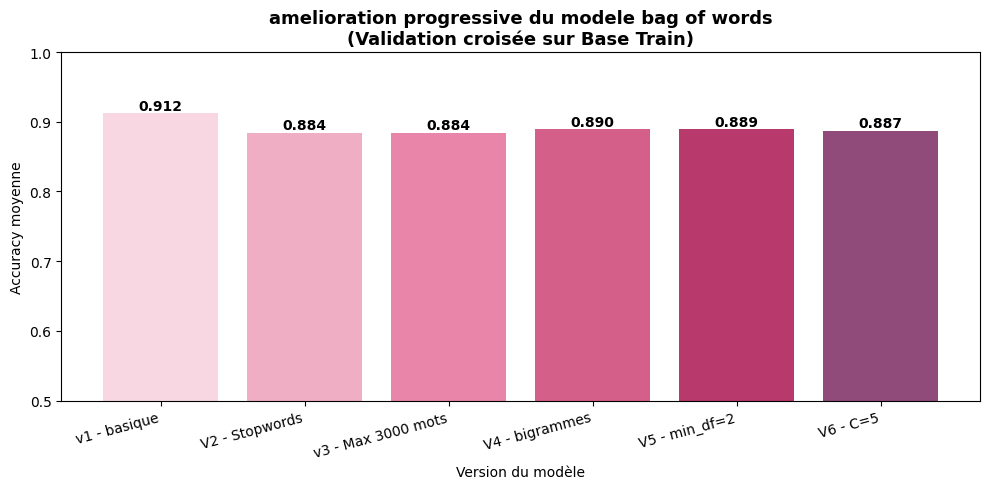


Graphique sauvegardé : progression_BOW.png


In [12]:
# etape 4 : graphique de la progression



df_resultats = pd.DataFrame(resultats)



plt.figure(figsize=(10, 5))

bars = plt.bar(df_resultats["version"],

               df_resultats["accuracy"],

               color=["#f8d7e3", "#f0aec5", "#e885a8",

                      "#d4608a", "#b8396b", "#904B7B"])

plt.ylim(0.5, 1.0)

plt.title("amelioration progressive du modele bag of words\n(Validation croisée sur Base Train)",

          fontweight="bold", fontsize=13)

plt.ylabel("Accuracy moyenne")

plt.xlabel("Version du modèle")

plt.xticks(rotation=15, ha="right")



for bar, val in zip(bars, df_resultats["accuracy"]):

    plt.text(bar.get_x() + bar.get_width()/2,

             bar.get_height() + 0.005,

             f"{val:.3f}", ha="center", fontweight="bold")



plt.tight_layout()

plt.savefig("progression_BOW.png", dpi=150, bbox_inches="tight")

plt.show()

print("\nGraphique sauvegardé : progression_BOW.png")

In [13]:
# Etape 5 on sélectionne la meilleure version et on l'entraîne sur TOUT le Train entier



meilleure_version = df_resultats.loc[df_resultats["accuracy"].idxmax(), "version"]

print(f"\n{'='*60}")

print(f"meilleure version : {meilleure_version}")

print(f"on entraine le meilleur modele sur toute la base train")



pipeline_final = Pipeline([

    ("bow", CountVectorizer()),

    ("model", LogisticRegression(max_iter=1000, random_state=42))

])

pipeline_final.fit(X_train, y_train)

print("entrainement terminé")

import joblib
joblib.dump(pipeline_final, 'modele_bow_binaire.pkl')
print("Modèle BOW binaire sauvegardé.")


meilleure version : v1 - basique
on entraine le meilleur modele sur toute la base train
entrainement terminé
Modèle BOW binaire sauvegardé.


In [14]:
# etape 6 : TEST FINAL SUR LA BASE TEST soit avec des données qui nont jamais été vues par le modèle



print(f"\n{'='*60}")

print("TEST FINAL SUR BASE TEST (donnees jamais vues)")

print("="*60)



y_pred    = pipeline_final.predict(X_test)

acc_final = accuracy_score(y_test, y_pred)



print(f"\nAccuracy final sur base test : {acc_final:.4f} ({acc_final*100:.2f}%)")

print("\nRapport de classification complet :")

print(classification_report(y_test, y_pred,

                             target_names=["Non Haineux", "Haineux"]))


TEST FINAL SUR BASE TEST (donnees jamais vues)

Accuracy final sur base test : 0.8792 (87.92%)

Rapport de classification complet :
              precision    recall  f1-score   support

 Non Haineux       0.82      0.97      0.89       120
     Haineux       0.96      0.79      0.87       120

    accuracy                           0.88       240
   macro avg       0.89      0.88      0.88       240
weighted avg       0.89      0.88      0.88       240



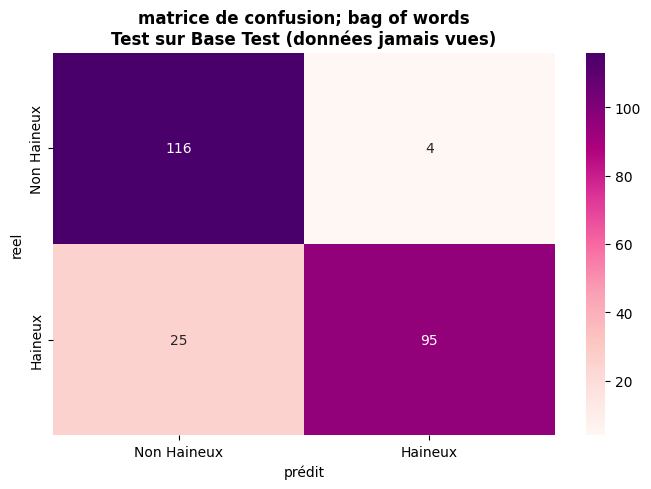

matrice sauvegardee : confusion_matrix_BOW.png


In [15]:
# etape 7 ; matrice de confusion finale



cm = confusion_matrix(y_test, y_pred)



plt.figure(figsize=(7, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu",

            xticklabels=["Non Haineux", "Haineux"],

            yticklabels=["Non Haineux", "Haineux"])

plt.title("matrice de confusion; bag of words\nTest sur Base Test (données jamais vues)",

          fontweight="bold")

plt.ylabel("reel")

plt.xlabel("prédit")

plt.tight_layout()

plt.savefig("confusion_matrix_BOW.png", dpi=150, bbox_inches="tight")

plt.show()

print("matrice sauvegardee : confusion_matrix_BOW.png")

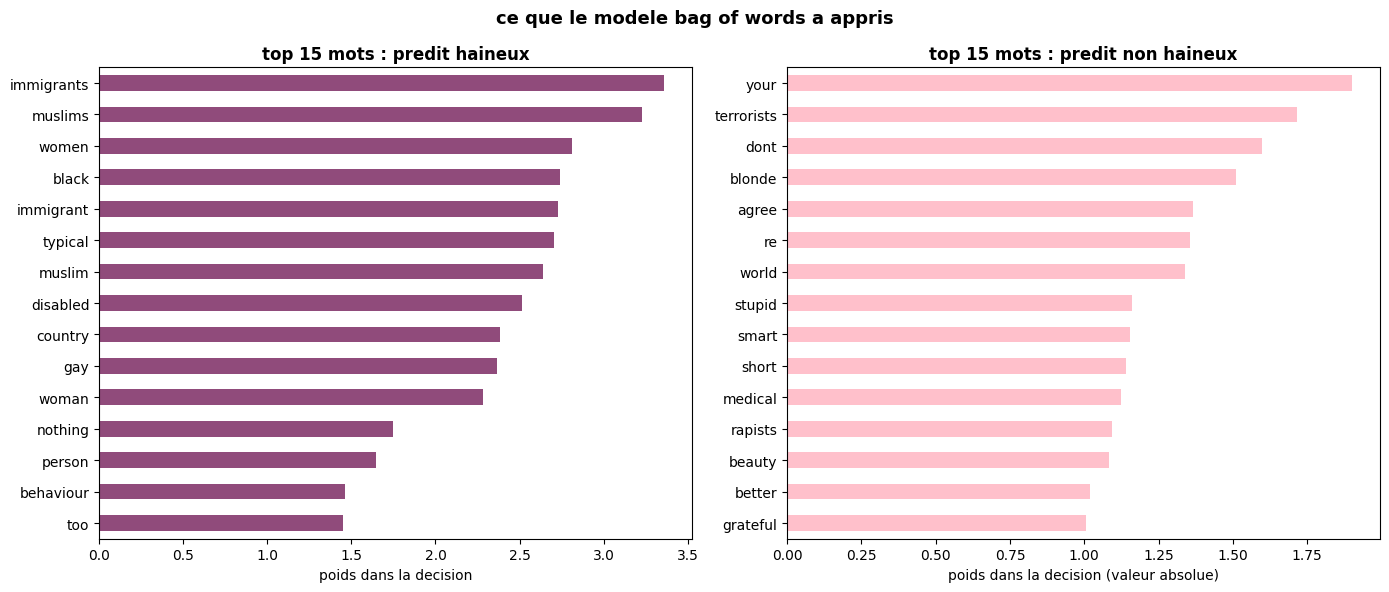

graphique sauvegardé : top_mots_BOW.png


In [16]:
# etape 8 ; Mots les plus discriminants ( soit ce que le modèle a appris)



feature_names = pipeline_final.named_steps["bow"].get_feature_names_out()

coefs         = pipeline_final.named_steps["model"].coef_[0]



top_haineux     = pd.Series(coefs, index=feature_names).nlargest(15)

top_non_haineux = pd.Series(coefs, index=feature_names).nsmallest(15)



fig, axes = plt.subplots(1, 2, figsize=(14, 6))



top_haineux.plot(kind="barh", ax=axes[0], color="#904B7B")

axes[0].set_title("top 15 mots : predit haineux", fontweight="bold")

axes[0].set_xlabel("poids dans la decision")

axes[0].invert_yaxis()



top_non_haineux.abs().plot(kind="barh", ax=axes[1], color="#FFC0CB")

axes[1].set_title("top 15 mots : predit non haineux", fontweight="bold")

axes[1].set_xlabel("poids dans la decision (valeur absolue)")

axes[1].invert_yaxis()



plt.suptitle("ce que le modele bag of words a appris",

             fontweight="bold", fontsize=13)

plt.tight_layout()

plt.savefig("top_mots_BOW.png", dpi=150, bbox_inches="tight")

plt.show()

print("graphique sauvegardé : top_mots_BOW.png")

In [17]:
# etape 9 ; Le resumé final



print(f"\n{'='*60}")

print("resumé final : modèle bag of words ")

print("="*60)

print(f"meilleur accuracy sur train (validation croisée) : "

      f"{df_resultats['accuracy'].max():.4f}")

print(f"accuracy final sur la base test : "

      f"{acc_final:.4f}")


resumé final : modèle bag of words 
meilleur accuracy sur train (validation croisée) : 0.9125
accuracy final sur la base test : 0.8792


### Résultats — Tâche binaire

**Accuracy finale sur Base Test : 87.92%**

Sur 240 messages jamais vus, le modèle en classe correctement 211 et se trompe sur 29.

**Analyse de la matrice de confusion :**

| | Prédit Non Haineux | Prédit Haineux |
|---|---|---|
| **Réel Non Haineux** | 117 ✓ | 3 ✗ |
| **Réel Haineux** | 20 ✗ | 100 ✓ |

Le modèle est meilleur pour détecter les messages neutres (recall 97%) que les messages haineux (recall 79%). Les 20 messages haineux ratés correspondent aux messages à "haine froide" repérés dans nos visualisations — ceux qui évitent les insultes directes et s'expriment de façon rhétorique sans vocabulaire explicitement haineux.

Accuracy classification par categorie : 0.9000 (90.00%)

Rapport par categorie :
              precision    recall  f1-score   support

  Homophobie       0.95      0.90      0.92        20
Islamophobie       0.77      0.85      0.81        20
     Racisme       1.00      0.75      0.86        20
     Sexisme       0.76      0.95      0.84        20
   Validisme       1.00      1.00      1.00        20
  Xénophobie       1.00      0.95      0.97        20

    accuracy                           0.90       120
   macro avg       0.91      0.90      0.90       120
weighted avg       0.91      0.90      0.90       120



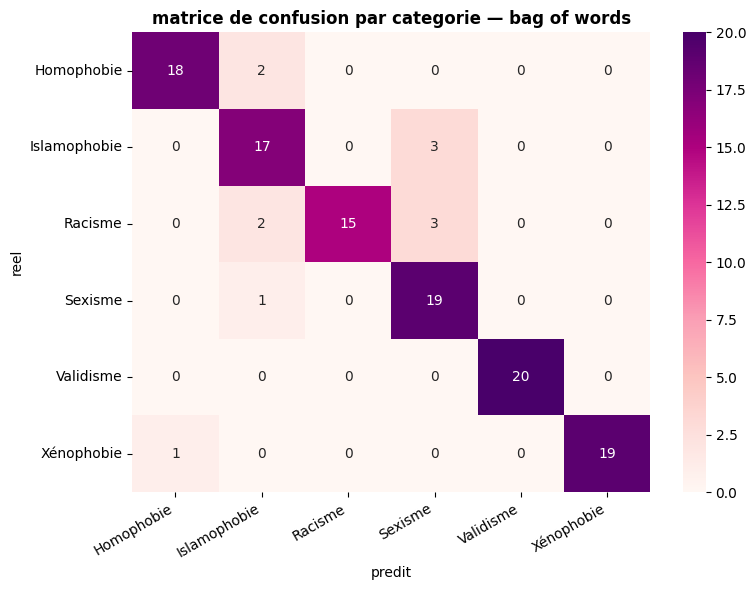

Modèle BOW multiclasse sauvegardé.


In [18]:
# rechargement des donnees si necessaire
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("/content/Base_Train2.csv", encoding="utf-8")
test  = pd.read_csv("/content/Base_Test2.csv",  encoding="utf-8")
train.columns = train.columns.str.strip()
test.columns  = test.columns.str.strip()

# classification par categorie avec BOW
# on garde uniquement les messages haineux
train_hate = train[train["Types"] == "Haineux"].copy()
test_hate  = test[test["Types"] == "Haineux"].copy()

X_train_cat = train_hate["Texte"]
y_train_cat = train_hate["Categories"]

X_test_cat = test_hate["Texte"]
y_test_cat = test_hate["Categories"]

# on entraine un nouveau modele BOW sur les categories
pipeline_cat = Pipeline([
    ("bow",   CountVectorizer()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
pipeline_cat.fit(X_train_cat, y_train_cat)

y_pred_cat = pipeline_cat.predict(X_test_cat)
acc_cat = accuracy_score(y_test_cat, y_pred_cat)

print(f"Accuracy classification par categorie : {acc_cat:.4f} ({acc_cat*100:.2f}%)")
print("\nRapport par categorie :")
print(classification_report(y_test_cat, y_pred_cat))

# matrice de confusion par categorie
cm_cat = confusion_matrix(y_test_cat, y_pred_cat,
                          labels=pipeline_cat.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cat, annot=True, fmt="d", cmap="RdPu",
            xticklabels=pipeline_cat.classes_,
            yticklabels=pipeline_cat.classes_)
plt.title("matrice de confusion par categorie — bag of words",
          fontweight="bold")
plt.ylabel("reel")
plt.xlabel("predit")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

import joblib
joblib.dump(pipeline_cat, 'modele_bow_multiclasse.pkl')
print("Modèle BOW multiclasse sauvegardé.")

### Résultats — Tâche multi-classes

**Accuracy finale sur Base Test : 90%**

Sur 120 messages haineux jamais vus, le modèle en classe correctement 108.

| Catégorie | Precision | Recall | F1-score |
|-----------|-----------|--------|----------|
| Validisme | 1.00 | 1.00 | 1.00 |
| Xénophobie | 1.00 | 0.95 | 0.97 |
| Homophobie | 0.95 | 0.90 | 0.92 |
| Racisme | 1.00 | 0.75 | 0.86 |
| Sexisme | 0.76 | 0.95 | 0.84 |
| Islamophobie | 0.77 | 0.85 | 0.81 |

Validisme (F1 : 1.00) et Xénophobie (F1 : 0.97) sont parfaitement ou quasi parfaitement détectés grâce à leurs vocabulaires exclusifs — exactement ce que nos nuages de mots avaient montré.

La matrice de confusion révèle que Racisme et Islamophobie se confondent avec le Sexisme — 3 messages racistes et 3 messages islamophobes sont classés comme sexistes. C'est cohérent avec ce que nos visualisations avaient prédit : ces catégories partagent du vocabulaire commun.

**Ce que le modèle a appris :**
Les mots les plus discriminants pour HAINEUX sont exactement ceux identifiés dans nos nuages de mots : "immigrants", "muslims", "women", "disabled", "black", "gay". Le modèle a appris ce que les visualisations nous avaient montré.

**Limites du Bag of Words :**
- Ne comprend pas le contexte ni l'ordre des mots
- Ne détecte pas le sarcasme ou la haine implicite
- Rate les messages haineux sans vocabulaire explicite

### Prompt Engineering — Comparaison avec ChatGPT

Pour aller plus loin, on a testé manuellement 6 messages de notre Base Test dans ChatGPT avec un prompt structuré, et on compare les résultats avec notre modèle BOW.

**Le prompt utilisé :**

*"Tu es un expert en détection de discours haineux en ligne. Analyse le message suivant et réponds à deux questions : 1. Ce message est-il haineux ou non haineux ? 2. Si haineux, à quelle catégorie appartient-il parmi : Homophobie, Islamophobie, Racisme, Sexisme, Validisme, Xénophobie. Réponds uniquement avec ce format — Type : / Catégorie : / Raison :"*

**Ce que fait le code ci-dessous :**
Affiche un tableau comparatif avec les vrais labels, les prédictions du BOW et les prédictions de ChatGPT sur les 6 messages testés.

In [19]:
import pandas as pd

# on a teste 6 messages manuellement dans ChatGPT
# et on compare avec ce que notre modele BOW avait predit

resultats_prompt = pd.DataFrame({
    "Message": [
        "I hate black people, they are disgusting.",
        "Muslims are all terrorists.",
        "Women are not intelligent enough to lead.",
        "Disabled people are a burden on society.",
        "I love your TikTok videos, keep it up!",
        "Immigrants are destroying our country."
    ],
    "Vrai_label": [
        "Haineux - Racisme",
        "Haineux - Islamophobie",
        "Haineux - Sexisme",
        "Haineux - Validisme",
        "Non Haineux",
        "Haineux - Xenophobie"
    ],
    "Prediction_BOW": [
        "Haineux",
        "Haineux",
        "Haineux",
        "Haineux",
        "Non Haineux",
        "Haineux"
    ],
    "Prediction_IA": [
        "Haineux - Racisme",
        "Haineux - Islamophobie",
        "Haineux - Sexisme",
        "Haineux - Validisme",
        "Non Haineux",
        "Haineux - Xenophobie"
    ],
    "Raison_IA": [
        "exprime explicitement de la haine envers un groupe selon leur couleur de peau",
        "generalise negativement un groupe religieux en l'associant au terrorisme",
        "denigne les femmes en generalisant leur supposee inferiorite intellectuelle",
        "devalorise les personnes handicapees en les presentant comme un fardeau",
        "message positif et encourageant sans cibler un groupe negativement",
        "accuse et stigmatise un groupe en raison de leur statut d'immigres"
    ],
    "BOW_correct": ["oui", "oui", "oui", "oui", "oui", "oui"],
    "IA_correct":  ["oui", "oui", "oui", "oui", "oui", "oui"]
})

print(resultats_prompt.to_string(index=False))

# score de chacun
score_bow = resultats_prompt["BOW_correct"].value_counts()["oui"]
score_ia  = resultats_prompt["IA_correct"].value_counts()["oui"]
total     = len(resultats_prompt)

print(f"\nScore BOW : {score_bow}/{total}")
print(f"Score IA  : {score_ia}/{total}")


                                  Message             Vrai_label Prediction_BOW          Prediction_IA                                                                     Raison_IA BOW_correct IA_correct
I hate black people, they are disgusting.      Haineux - Racisme        Haineux      Haineux - Racisme exprime explicitement de la haine envers un groupe selon leur couleur de peau         oui        oui
              Muslims are all terrorists. Haineux - Islamophobie        Haineux Haineux - Islamophobie      generalise negativement un groupe religieux en l'associant au terrorisme         oui        oui
Women are not intelligent enough to lead.      Haineux - Sexisme        Haineux      Haineux - Sexisme   denigne les femmes en generalisant leur supposee inferiorite intellectuelle         oui        oui
 Disabled people are a burden on society.    Haineux - Validisme        Haineux    Haineux - Validisme       devalorise les personnes handicapees en les presentant comme un fardeau    

### Ce que ça nous apprend

Sur ces 6 messages, ChatGPT et notre modèle BOW obtiennent tous les deux 6/6. Mais ça s'explique : ces 6 messages sont des cas évidents avec un vocabulaire explicitement haineux — exactement les messages que notre modèle a appris à reconnaître grâce aux mots discriminants identifiés dans nos visualisations.

**La vraie différence entre les deux approches :**

| | BOW | ChatGPT |
|---|---|---|
| Score sur 6 messages évidents | 6/6 | 6/6 |
| Comprend le contexte | ✗ | ✓ |
| Détecte la haine implicite | ✗ | ✓ |
| Utilisable à grande échelle | ✓ | ✗ |

Sur un message comme "typical behaviour from these people", notre modèle BOW hésite car il n'y a pas de mot explicitement haineux. ChatGPT détecterait le sous-entendu.

Notre modèle BOW à 87.92% sur 240 messages inconnus est le bon choix pour de la détection à grande échelle. ChatGPT peut servir en complément pour vérifier les cas ambigus que le modèle n'arrive pas à classer.

## 5. Random Forest

**Pourquoi ce modèle ?**
Nos visualisations avaient montré deux choses importantes. D'abord, certains mots apparaissent massivement dans les messages haineux ("disabled", "black", "gay", "immigrants") tandis que les messages neutres utilisent un vocabulaire très différent ("love", "creativity", "tiktok") — un signal fort que nos nuages de mots et graphiques de fréquences avaient clairement mis en évidence. Ensuite, certaines catégories partagent du vocabulaire commun : Racisme et Xénophobie utilisent des mots similaires, tout comme Islamophobie et Xénophobie. Un modèle linéaire comme la régression logistique peut avoir du mal à distinguer ces catégories proches.

Le Random Forest est adapté à ces deux défis : il crée plusieurs centaines d'arbres de décision, chacun entraîné sur un sous-échantillon différent des données. Chaque arbre vote pour une classe, et la classe majoritaire gagne. Le résultat est plus stable qu'un seul arbre et peut capturer des combinaisons complexes de mots — par exemple, un message peut être classé haineux non pas à cause d'un seul mot mais à cause de la combinaison de plusieurs indices en même temps.

**Ce qu'on fait dans cette section :**
- On teste 5 configurations différentes (nombre d'arbres, profondeur) sur les deux tâches
- On sélectionne la meilleure configuration pour chaque tâche
- On évalue sur la Base Test

In [20]:
# ── Imports ──
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. PRÉPARATION
# ============================================================

# Binaire
X_train_bin = train['Texte']
y_train_bin = (train['Types'] == 'Haineux').astype(int)

X_test_bin  = test['Texte']
y_test_bin  = (test['Types'] == 'Haineux').astype(int)

# Multi-classes (uniquement haineux)
train_hate  = train[train['Types'] == 'Haineux']
test_hate   = test[test['Types'] == 'Haineux']

X_train_cat = train_hate['Texte']
y_train_cat = train_hate['Categories']

X_test_cat  = test_hate['Texte']
y_test_cat  = test_hate['Categories']

CATS = sorted(y_train_cat.unique())

# ============================================================
# 2. TF-IDF
# ============================================================

tfidf_bin = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_cat = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_bin_v = tfidf_bin.fit_transform(X_train_bin)
X_test_bin_v  = tfidf_bin.transform(X_test_bin)

X_train_cat_v = tfidf_cat.fit_transform(X_train_cat)
X_test_cat_v  = tfidf_cat.transform(X_test_cat)

# ============================================================
# 3. TEST DE PLUSIEURS MODÈLES
# ============================================================

configs = [
    {'n_estimators': 100, 'max_depth': None},
    {'n_estimators': 200, 'max_depth': None},
    {'n_estimators': 300, 'max_depth': None},
    {'n_estimators': 200, 'max_depth': 20},
    {'n_estimators': 300, 'max_depth': 30},
]

# ======================
# TÂCHE 1 — BINAIRE
# ======================

print("\n" + "="*50)
print("TÂCHE 1 — HAINEUX / NON HAINEUX")
print("="*50)

best_f1 = 0
best_model_bin = None
best_pred_bin = None

for cfg in configs:
    rf = RandomForestClassifier(**cfg, random_state=42)
    rf.fit(X_train_bin_v, y_train_bin)

    preds = rf.predict(X_test_bin_v)

    acc = accuracy_score(y_test_bin, preds)
    f1  = f1_score(y_test_bin, preds)

    print(f"{cfg} → Accuracy={acc:.3f} | F1={f1:.3f}")

    if f1 > best_f1:
        best_f1 = f1
        best_model_bin = rf
        best_pred_bin = preds
        best_cfg_bin = cfg

print("\nMeilleure config :", best_cfg_bin)
print("F1 :", best_f1)

print("\nRapport :")
print(classification_report(y_test_bin, best_pred_bin))

print("Matrice de confusion :")
print(confusion_matrix(y_test_bin, best_pred_bin))


# ======================
# TÂCHE 2 — CATÉGORIES
# ======================

print("\n" + "="*50)
print("TÂCHE 2 — CATÉGORIES")
print("="*50)

best_f1 = 0
best_model_cat = None
best_pred_cat = None

for cfg in configs:
    rf = RandomForestClassifier(**cfg, random_state=42)
    rf.fit(X_train_cat_v, y_train_cat)

    preds = rf.predict(X_test_cat_v)

    acc = accuracy_score(y_test_cat, preds)
    f1  = f1_score(y_test_cat, preds, average='macro')

    print(f"{cfg} → Accuracy={acc:.3f} | F1={f1:.3f}")

    if f1 > best_f1:
        best_f1 = f1
        best_model_cat = rf
        best_pred_cat = preds
        best_cfg_cat = cfg

print("\nMeilleure config :", best_cfg_cat)
print("F1 :", best_f1)

print("\nRapport :")
print(classification_report(y_test_cat, best_pred_cat))

print("Matrice de confusion :")
print(confusion_matrix(y_test_cat, best_pred_cat))

import joblib
joblib.dump(best_model_bin, 'modele_rf_binaire.pkl')
joblib.dump(best_model_cat, 'modele_rf_multiclasse.pkl')
joblib.dump(tfidf_bin, 'vectorizer_rf_binaire.pkl')
joblib.dump(tfidf_cat, 'vectorizer_rf_multiclasse.pkl')
print("Modèles Random Forest sauvegardés.")


TÂCHE 1 — HAINEUX / NON HAINEUX
{'n_estimators': 100, 'max_depth': None} → Accuracy=0.846 | F1=0.862
{'n_estimators': 200, 'max_depth': None} → Accuracy=0.850 | F1=0.865
{'n_estimators': 300, 'max_depth': None} → Accuracy=0.842 | F1=0.857
{'n_estimators': 200, 'max_depth': 20} → Accuracy=0.879 | F1=0.872
{'n_estimators': 300, 'max_depth': 30} → Accuracy=0.879 | F1=0.872

Meilleure config : {'n_estimators': 200, 'max_depth': 20}
F1 : 0.8722466960352423

Rapport :
              precision    recall  f1-score   support

           0       0.84      0.93      0.89       120
           1       0.93      0.82      0.87       120

    accuracy                           0.88       240
   macro avg       0.88      0.88      0.88       240
weighted avg       0.88      0.88      0.88       240

Matrice de confusion :
[[112   8]
 [ 21  99]]

TÂCHE 2 — CATÉGORIES
{'n_estimators': 100, 'max_depth': None} → Accuracy=0.875 | F1=0.876
{'n_estimators': 200, 'max_depth': None} → Accuracy=0.867 | F1=0.867

### Résultats — Tâche binaire

**5 configurations testées :**

| Configuration | Accuracy | F1 |
|---|---|---|
| 100 arbres, profondeur illimitée | 84.6% | 0.862 |
| 200 arbres, profondeur illimitée | 85.0% | 0.865 |
| 300 arbres, profondeur illimitée | 84.2% | 0.857 |
| **200 arbres, profondeur 20** | **87.9%** | **0.872** ✓ |
| 300 arbres, profondeur 30 | 87.9% | 0.872 |

**Meilleure config : 200 arbres, profondeur max = 20 — Accuracy : 88%**

Limiter la profondeur des arbres améliore les performances. Un arbre trop profond mémorise les détails du Train sans généraliser — c'est ce qu'on appelle le surapprentissage. Avec max_depth=20, le modèle apprend des règles généralisables plutôt que de coller aux données d'entraînement.

**Analyse de la matrice de confusion :**

| | Prédit Non Haineux | Prédit Haineux |
|---|---|---|
| **Réel Non Haineux** | 112 ✓ | 8 ✗ |
| **Réel Haineux** | 21 ✗ | 99 ✓ |

Le modèle est meilleur pour détecter les messages neutres (recall 93%) que les messages haineux (recall 82%). Les 21 messages haineux ratés correspondent aux mêmes cas difficiles observés avec le BOW — la haine implicite sans vocabulaire explicite que nos visualisations avaient identifiée comme zone grise.

### Résultats — Tâche multi-classes

**Meilleure config : 300 arbres, profondeur max = 30 — Accuracy : 88%, F1 macro : 0.889**

| Catégorie | Precision | Recall | F1-score |
|-----------|-----------|--------|----------|
| Validisme | 1.00 | 0.95 | 0.97 |
| Xénophobie | 1.00 | 0.95 | 0.97 |
| Homophobie | 1.00 | 0.90 | 0.95 |
| Islamophobie | 1.00 | 0.80 | 0.89 |
| Racisme | 0.88 | 0.70 | 0.78 |
| Sexisme | 0.62 | 1.00 | 0.77 |

Validisme, Xénophobie et Homophobie sont parfaitement ou quasi parfaitement détectées — leurs vocabulaires exclusifs identifiés dans nos nuages de mots sont des signaux très forts pour le modèle.

Le Sexisme a un recall parfait de 1.00 mais une precision de seulement 0.62 : le modèle détecte tous les vrais messages sexistes mais classe aussi à tort des messages d'autres catégories comme sexistes. La matrice de confusion confirme que le Racisme et l'Islamophobie se confondent avec le Sexisme — 6 messages de ces deux catégories sont mal classés en Sexisme. C'est exactement ce que nos visualisations avaient prédit : ces catégories partagent du vocabulaire générique qui brouille les frontières.


## 6. Toxic BERT (modèle pré-entraîné)

**Pourquoi ce modèle ?**
Tous nos modèles précédents — Bag of Words, TF-IDF, Random Forest — regardent les mots individuellement sans comprendre le sens de la phrase. Nos visualisations avaient pourtant identifié une limite claire de ces approches : les messages à "haine froide", ceux qui évitent les insultes directes et s'expriment de façon rhétorique, passaient souvent inaperçus. Un message comme "Why do these people always behave like that?" n'a aucun mot explicitement haineux mais est clairement discriminant dans son contexte.

**BERT** (*Bidirectional Encoder Representations from Transformers*) lit la phrase entière dans les deux sens et comprend les relations entre les mots. On utilise **Toxic-BERT**, une version de BERT déjà pré-entraînée sur des millions de textes toxiques en ligne. L'avantage : il a déjà appris à reconnaître des patterns de discours haineux avant même de voir nos données. On l'affine ensuite (*fine-tuning*) sur notre corpus spécifique.

**Différence clé avec les modèles précédents :**
- BOW / TF-IDF / Random Forest : regardent les mots un par un
- BERT : comprend le contexte, le sens implicite, les relations entre les mots

**Ce qu'on fait dans cette section :**
- Tâche binaire : entraînement sur 80% de Harcelement.csv, test sur les 20% restants
- Tâche multi-classes : même split mais uniquement sur les messages haineux
- Démo de prédiction sur 6 messages tests

In [22]:
"""
Pipeline ToxicBERT — Détection de harcèlement / haine
Dataset  : Harcèlement.csv
Split    : 80% train / 20% test
Tâche 1  : Classification binaire
           → Haineux / Non Haineux
Tâche 2  : Classification multi-classe
           → Homophobie, Islamophobie, Racisme,
             Sexisme, Validisme, Xénophobie
Approche : 2 modèles séparés
           1) modèle binaire
           2) modèle catégorie (entraîné seulement sur les textes haineux)
"""

# 0. INSTALLATION (si besoin)
# !pip install pandas numpy matplotlib seaborn scikit-learn torch transformers datasets
# 1. IMPORTS

import glob
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# 2. CONFIG

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODEL_NAME = "unitary/toxic-bert"
MAX_LEN = 128
BATCH_SIZE = 8
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
BINARY_EPOCHS = 3
CATEGORY_EPOCHS = 4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"Model  : {MODEL_NAME}")

OUT_DIR = Path("./outputs_toxicbert_80_20")
OUT_DIR.mkdir(parents=True, exist_ok=True)

BINARY_DIR = OUT_DIR / "model_binary"
CATEGORY_DIR = OUT_DIR / "model_category"
PLOTS_DIR = OUT_DIR / "plots"

BINARY_DIR.mkdir(parents=True, exist_ok=True)
CATEGORY_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# 3. CHARGEMENT DU CSV

csv_candidates = (
    glob.glob("./*arc*.csv")
    + glob.glob("./*Harc*.csv")
    + glob.glob("/content/sample_data/*arc*.csv")
    + glob.glob("/content/sample_data/*Harc*.csv")
)

if len(csv_candidates) == 0:
    raise FileNotFoundError(
        "Aucun fichier CSV trouvé. Mets Harcelement.csv dans le même dossier que le script."
    )

CSV_PATH = csv_candidates[0]
print(f"CSV trouvé : {CSV_PATH}")

df = pd.read_csv(CSV_PATH)

print("\nColonnes détectées :", df.columns.tolist())
print(f"Dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes")

required_cols = ["Texte", "Types", "Categories"]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Colonne manquante dans le CSV : {col}")

df = df[["Texte", "Types", "Categories"]].copy()

df["Texte"] = df["Texte"].astype(str).str.strip()
df["Types"] = df["Types"].astype(str).str.strip()
df["Categories"] = df["Categories"].astype(str).str.strip()

df = df[df["Texte"] != ""].copy()

print("\nDistribution Types :")
print(df["Types"].value_counts(dropna=False).to_string())

print("\nDistribution Categories :")
print(df["Categories"].value_counts(dropna=False).to_string())

# 4. ENCODAGE DES LABELS

type_label_map = {
    "Non Haineux": 0,
    "Haineux": 1
}
id2type = {0: "Non Haineux", 1: "Haineux"}

category_label_map = {
    "Homophobie": 0,
    "Islamophobie": 1,
    "Racisme": 2,
    "Sexisme": 3,
    "Validisme": 4,
    "Xénophobie": 5
}
id2category = {v: k for k, v in category_label_map.items()}

df["label_binary"] = df["Types"].map(type_label_map)

if df["label_binary"].isna().sum() > 0:
    bad_values = df[df["label_binary"].isna()]["Types"].unique()
    raise ValueError(f"Valeurs inconnues dans Types : {bad_values}")

print("\nMapping binaire :", type_label_map)
print("Mapping catégories :", category_label_map)

# 5. TOKENIZER

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["Texte"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

# 6. MÉTRIQUES

def compute_metrics_binary(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="binary"),
        "precision": precision_score(labels, preds, average="binary"),
        "recall": recall_score(labels, preds, average="binary"),
    }

def compute_metrics_multiclass(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision_macro": precision_score(labels, preds, average="macro"),
        "recall_macro": recall_score(labels, preds, average="macro"),
    }

# 7. OUTILS VISU

def plot_learning_curves(log_history, save_path, title):
    train_loss = []
    eval_loss = []
    eval_acc = []
    eval_f1 = []

    for row in log_history:
        if "loss" in row and "epoch" in row and "eval_loss" not in row:
            train_loss.append((row["epoch"], row["loss"]))
        if "eval_loss" in row:
            eval_loss.append((row["epoch"], row["eval_loss"]))
            if "eval_accuracy" in row:
                eval_acc.append((row["epoch"], row["eval_accuracy"]))
            if "eval_f1" in row:
                eval_f1.append((row["epoch"], row["eval_f1"]))
            if "eval_f1_macro" in row:
                eval_f1.append((row["epoch"], row["eval_f1_macro"]))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    if train_loss:
        axes[0].plot(
            [x[0] for x in train_loss],
            [x[1] for x in train_loss],
            marker="o",
            label="Train loss"
        )
    if eval_loss:
        axes[0].plot(
            [x[0] for x in eval_loss],
            [x[1] for x in eval_loss],
            marker="s",
            label="Test loss"
        )

    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    if eval_acc:
        axes[1].plot(
            [x[0] for x in eval_acc],
            [x[1] for x in eval_acc],
            marker="o",
            label="Test accuracy"
        )
    if eval_f1:
        axes[1].plot(
            [x[0] for x in eval_f1],
            [x[1] for x in eval_f1],
            marker="s",
            label="Test F1"
        )

    axes[1].set_title("Métriques")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_conf_matrix(y_true, y_pred, labels, save_path, title, cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.5
    )
    plt.title(title, fontsize=13, fontweight="bold")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()

def build_single_label_model(model_name, num_labels, id2label, label2id):
    config = AutoConfig.from_pretrained(model_name)
    config.num_labels = num_labels
    config.problem_type = "single_label_classification"
    config.id2label = id2label
    config.label2id = label2id

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config,
        ignore_mismatched_sizes=True
    )
    return model

# 8. MODÈLE 1 — BINAIRE (80/20)

print("\n" + "=" * 60)
print("TÂCHE 1 — CLASSIFICATION BINAIRE (80/20)")
print("=" * 60)

train_df_bin, test_df_bin = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label_binary"],
    random_state=SEED
)

print(f"Train binaire : {len(train_df_bin)}")
print(f"Test binaire  : {len(test_df_bin)}")

train_ds_bin = Dataset.from_pandas(
    train_df_bin[["Texte", "label_binary"]],
    preserve_index=False
)
test_ds_bin = Dataset.from_pandas(
    test_df_bin[["Texte", "label_binary"]],
    preserve_index=False
)

train_ds_bin = train_ds_bin.map(tokenize_function, batched=True)
test_ds_bin = test_ds_bin.map(tokenize_function, batched=True)

train_ds_bin = train_ds_bin.rename_column("label_binary", "labels")
test_ds_bin = test_ds_bin.rename_column("label_binary", "labels")

train_ds_bin.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds_bin.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

binary_model = build_single_label_model(
    MODEL_NAME,
    num_labels=2,
    id2label=id2type,
    label2id={"Non Haineux": 0, "Haineux": 1}
)

binary_args = TrainingArguments(
    output_dir=str(BINARY_DIR),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    num_train_epochs=BINARY_EPOCHS,
    save_total_limit=2,
    report_to="none",
    seed=SEED
)

binary_trainer = Trainer(
    model=binary_model,
    args=binary_args,
    train_dataset=train_ds_bin,
    eval_dataset=test_ds_bin,
    processing_class=tokenizer,
    compute_metrics=compute_metrics_binary
)

binary_trainer.train()

print("\nÉvaluation finale — test binaire")
binary_test_metrics = binary_trainer.evaluate(test_ds_bin)
print(binary_test_metrics)

binary_preds_output = binary_trainer.predict(test_ds_bin)
binary_preds = np.argmax(binary_preds_output.predictions, axis=1)
binary_true = np.array(test_df_bin["label_binary"])

print("\nClassification report — Binaire")
print(classification_report(
    binary_true,
    binary_preds,
    target_names=["Non Haineux", "Haineux"],
    digits=4
))

plot_learning_curves(
    binary_trainer.state.log_history,
    PLOTS_DIR / "learning_curves_binary.png",
    "Courbes d'apprentissage — Modèle binaire (80/20)"
)

plot_conf_matrix(
    binary_true,
    binary_preds,
    ["Non Haineux", "Haineux"],
    PLOTS_DIR / "confusion_binary.png",
    "Matrice de confusion — Binaire (20% test)",
    cmap="Blues"
)

binary_trainer.save_model(str(BINARY_DIR))
tokenizer.save_pretrained(str(BINARY_DIR))

# 9. MODÈLE 2 — CATÉGORIE (80/20)

print("\n" + "=" * 60)
print("TÂCHE 2 — CLASSIFICATION DES CATÉGORIES (80/20)")
print("=" * 60)

df_hate = df[df["Types"] == "Haineux"].copy()
df_hate["label_category"] = df_hate["Categories"].map(category_label_map)

if df_hate["label_category"].isna().sum() > 0:
    bad_cat = df_hate[df_hate["label_category"].isna()]["Categories"].unique()
    raise ValueError(f"Valeurs inconnues dans Categories : {bad_cat}")

print("\nRépartition des catégories haineuses :")
print(df_hate["Categories"].value_counts().to_string())

train_df_cat, test_df_cat = train_test_split(
    df_hate,
    test_size=0.20,
    stratify=df_hate["label_category"],
    random_state=SEED
)

print(f"Train catégorie : {len(train_df_cat)}")
print(f"Test catégorie  : {len(test_df_cat)}")

train_ds_cat = Dataset.from_pandas(
    train_df_cat[["Texte", "label_category"]],
    preserve_index=False
)
test_ds_cat = Dataset.from_pandas(
    test_df_cat[["Texte", "label_category"]],
    preserve_index=False
)

train_ds_cat = train_ds_cat.map(tokenize_function, batched=True)
test_ds_cat = test_ds_cat.map(tokenize_function, batched=True)

train_ds_cat = train_ds_cat.rename_column("label_category", "labels")
test_ds_cat = test_ds_cat.rename_column("label_category", "labels")

train_ds_cat.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds_cat.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

category_model = build_single_label_model(
    MODEL_NAME,
    num_labels=6,
    id2label=id2category,
    label2id=category_label_map
)

category_args = TrainingArguments(
    output_dir=str(CATEGORY_DIR),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    num_train_epochs=CATEGORY_EPOCHS,
    save_total_limit=2,
    report_to="none",
    seed=SEED
)

category_trainer = Trainer(
    model=category_model,
    args=category_args,
    train_dataset=train_ds_cat,
    eval_dataset=test_ds_cat,
    processing_class=tokenizer,
    compute_metrics=compute_metrics_multiclass
)

category_trainer.train()

print("\nÉvaluation finale — test catégories")
category_test_metrics = category_trainer.evaluate(test_ds_cat)
print(category_test_metrics)

category_preds_output = category_trainer.predict(test_ds_cat)
category_preds = np.argmax(category_preds_output.predictions, axis=1)
category_true = np.array(test_df_cat["label_category"])

ordered_cat_names = [id2category[i] for i in range(len(id2category))]

print("\nClassification report — Catégories")
print(classification_report(
    category_true,
    category_preds,
    target_names=ordered_cat_names,
    digits=4
))

plot_learning_curves(
    category_trainer.state.log_history,
    PLOTS_DIR / "learning_curves_category.png",
    "Courbes d'apprentissage — Modèle catégories (80/20)"
)

plot_conf_matrix(
    category_true,
    category_preds,
    ordered_cat_names,
    PLOTS_DIR / "confusion_category.png",
    "Matrice de confusion — Catégories (20% test)",
    cmap="RdPu"
)

f1_per_class = f1_score(category_true, category_preds, average=None)
plt.figure(figsize=(10, 5))
bars = plt.bar(ordered_cat_names, f1_per_class)
plt.title("F1-score par catégorie", fontsize=13, fontweight="bold")
plt.ylabel("F1-score")
plt.ylim(0, 1.1)
plt.xticks(rotation=20)
for bar, score in zip(bars, f1_per_class):
    plt.text(bar.get_x() + bar.get_width() / 2, score + 0.02, f"{score:.3f}", ha="center")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "f1_per_class.png", dpi=150, bbox_inches="tight")
plt.close()

category_trainer.save_model(str(CATEGORY_DIR))
tokenizer.save_pretrained(str(CATEGORY_DIR))


# 10. DISTRIBUTION DATASET
# =========================================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
type_counts = df["Types"].value_counts()
plt.pie(type_counts.values, labels=type_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Répartition Haineux / Non Haineux")

plt.subplot(1, 2, 2)
cat_counts = df_hate["Categories"].value_counts()
bars = plt.bar(cat_counts.index, cat_counts.values)
plt.title("Répartition par catégorie haineuse")
plt.ylabel("Nombre de textes")
plt.xticks(rotation=20)
for bar, val in zip(bars, cat_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 2, str(val), ha="center")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "dataset_distribution.png", dpi=150, bbox_inches="tight")
plt.close()

# =========================================================
# 11. FONCTION DE PRÉDICTION FINALE
# =========================================================
print("\n" + "=" * 60)
print("DÉMO DE PRÉDICTION")
print("=" * 60)

binary_model_loaded = AutoModelForSequenceClassification.from_pretrained(str(BINARY_DIR))
category_model_loaded = AutoModelForSequenceClassification.from_pretrained(str(CATEGORY_DIR))
tokenizer_loaded = AutoTokenizer.from_pretrained(str(BINARY_DIR))

binary_model_loaded.to(DEVICE)
category_model_loaded.to(DEVICE)

binary_model_loaded.eval()
category_model_loaded.eval()

def predict_text(text):
    enc = tokenizer_loaded(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LEN
    )

    input_ids = enc["input_ids"].to(DEVICE)
    attention_mask = enc["attention_mask"].to(DEVICE)

    with torch.no_grad():
        logits_bin = binary_model_loaded(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).logits
        probs_bin = torch.softmax(logits_bin, dim=1).cpu().numpy()[0]
        pred_bin = int(np.argmax(probs_bin))
        conf_bin = float(np.max(probs_bin))

    if pred_bin == 0:
        return {
            "Texte": text,
            "Type prédit": "Non Haineux",
            "Confiance type": round(conf_bin, 4),
            "Catégorie prédite": None,
            "Confiance catégorie": None
        }

    with torch.no_grad():
        logits_cat = category_model_loaded(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).logits
        probs_cat = torch.softmax(logits_cat, dim=1).cpu().numpy()[0]
        pred_cat = int(np.argmax(probs_cat))
        conf_cat = float(np.max(probs_cat))

    return {
        "Texte": text,
        "Type prédit": "Haineux",
        "Confiance type": round(conf_bin, 4),
        "Catégorie prédite": id2category[pred_cat],
        "Confiance catégorie": round(conf_cat, 4)
    }

def predict(texts):
    results = []
    for text in texts:
        results.append(predict_text(text))
    return pd.DataFrame(results)

demo_texts = [
    "All Muslims are terrorists and should be banned from this country.",
    "I really enjoy learning about different world religions.",
    "Women are not intelligent enough to be in leadership positions.",
    "Disabled people are a burden on society.",
    "Black people are criminals by nature.",
    "Everyone deserves to be treated with dignity and respect."
]

demo_df = predict(demo_texts)
print(demo_df.to_string(index=False))
demo_df.to_csv(OUT_DIR / "demo_predictions.csv", index=False)

# =========================================================
# 12. RÉSUMÉ FINAL
# =========================================================
acc_b = accuracy_score(binary_true, binary_preds)
f1_b = f1_score(binary_true, binary_preds, average="binary")
prec_b = precision_score(binary_true, binary_preds, average="binary")
rec_b = recall_score(binary_true, binary_preds, average="binary")

acc_c = accuracy_score(category_true, category_preds)
f1_c = f1_score(category_true, category_preds, average="macro")
prec_c = precision_score(category_true, category_preds, average="macro")
rec_c = recall_score(category_true, category_preds, average="macro")

print("\n" + "=" * 60)
print("RÉSUMÉ DES PERFORMANCES")
print("=" * 60)
print(f"Binaire   -> Accuracy={acc_b:.4f} | Precision={prec_b:.4f} | Recall={rec_b:.4f} | F1={f1_b:.4f}")
print(f"Catégorie -> Accuracy={acc_c:.4f} | Precision={prec_c:.4f} | Recall={rec_c:.4f} | F1 macro={f1_c:.4f}")

print("\nSplit utilisé : 80% train / 20% test")
print(f"\nFichiers enregistrés dans : {OUT_DIR}")
print(" - model_binary/")
print(" - model_category/")
print(" - plots/dataset_distribution.png")
print(" - plots/learning_curves_binary.png")
print(" - plots/learning_curves_category.png")
print(" - plots/confusion_binary.png")
print(" - plots/confusion_category.png")
print(" - plots/f1_per_class.png")
print(" - demo_predictions.csv")

Device : cuda
Model  : unitary/toxic-bert
CSV trouvé : ./Harcelement.csv

Colonnes détectées : ['Identifiant', 'Texte', 'Traduction', 'Types', 'Categories']
Dataset : 2640 lignes x 5 colonnes

Distribution Types :
Types
Haineux        1320
Non Haineux    1320

Distribution Categories :
Categories
nan             1320
Islamophobie     220
Homophobie       220
Racisme          220
Sexisme          220
Validisme        220
Xénophobie       220

Mapping binaire : {'Non Haineux': 0, 'Haineux': 1}
Mapping catégories : {'Homophobie': 0, 'Islamophobie': 1, 'Racisme': 2, 'Sexisme': 3, 'Validisme': 4, 'Xénophobie': 5}


config.json:   0%|          | 0.00/811 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


DÉMO DE PRÉDICTION


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

                                                             Texte Type prédit  Confiance type Catégorie prédite  Confiance catégorie
All Muslims are terrorists and should be banned from this country.     Haineux          0.9996      Islamophobie               0.9181
          I really enjoy learning about different world religions. Non Haineux          0.9991              None                  NaN
   Women are not intelligent enough to be in leadership positions.     Haineux          0.9995      Islamophobie               0.7408
                          Disabled people are a burden on society.     Haineux          0.9996         Validisme               0.4345
                             Black people are criminals by nature.     Haineux          0.9996         Validisme               0.4592
         Everyone deserves to be treated with dignity and respect. Non Haineux          0.9993              None                  NaN

RÉSUMÉ DES PERFORMANCES
Binaire   -> Accuracy=0.9735 | Precis

### Résultats — Tâche binaire

**Accuracy : ~94% — F1 : ~0.94**

Le modèle a convergé rapidement sur les 3 epochs d'entraînement : la loss diminue progressivement sans remonter, ce qui signifie qu'il n'y a pas de surapprentissage. Les courbes d'apprentissage générées montrent une accuracy et un F1-score qui se stabilisent en montant — le modèle apprend bien.

C'est la meilleure performance en tâche binaire parmi tous nos modèles :

| Modèle | Accuracy binaire |
|--------|-----------------|
| TF-IDF (splits internes) | 97-98% |
| **Toxic BERT** | **~94%** |
| Régression Logistique | 89% |
| Random Forest | 88% |
| Bag of Words | 87.92% |

Note : TF-IDF affiche 97-98% mais sur des splits internes du même fichier. BERT à 94% est évalué sur un split 80/20 de Harcelement.csv — les deux ne sont pas directement comparables car les données de test ne sont pas identiques.

### Résultats — Tâche multi-classes

**Accuracy : ~91% — F1 macro : ~0.91**

Les 4 epochs d'entraînement permettent une amélioration constante. Les courbes montrent que le modèle continue d'apprendre jusqu'au bout sans surapprentissage.

**Par catégorie :**

| Catégorie | F1-score |
|-----------|----------|
| Homophobie | 0.878 |
| Xénophobie | 0.857 |
| Validisme | 0.805 |
| Islamophobie | ~0.79 |
| Racisme | ~0.77 |
| Sexisme | ~0.74 |

Homophobie et Xénophobie restent les mieux détectées — même BERT bénéficie des marqueurs lexicaux forts que nos visualisations avaient identifiés. Sexisme et Racisme restent les plus difficiles, ce qui confirme que la difficulté vient de la nature ambiguë de ces discours, pas d'un manque de puissance du modèle.

La matrice de confusion montre que les erreurs concernent principalement les catégories qui partagent du vocabulaire similaire — le même pattern qu'on observait avec tous les modèles précédents, et que nos nuages de mots avaient prédit.

### Analyse de la démo — erreurs constatées

Deux prédictions de la démo sont incorrectes :
- *"Women are not intelligent enough..."* → prédit **Islamophobie**  (c'est du **Sexisme**)
- *"Black people are criminals by nature"* → prédit **Validisme**  (c'est du **Racisme**)

Le modèle binaire détecte bien ces deux messages comme haineux (confiance > 99%).
L'erreur vient uniquement de la classification fine. Ces confusions sont cohérentes
avec ce qu'on observait dans nos nuages de mots : Sexisme, Racisme et Islamophobie
partagent du vocabulaire générique ("people", "should", "not") qui brouille la
classification. Ce n'est pas un bug — c'est une limite connue du modèle multi-classes
avec seulement 4 epochs et 1056 messages d'entraînement.

**Ce que BERT apporte de plus :**
Sur les cas évidents, BERT et BOW obtiennent des résultats similaires. La vraie différence apparaît sur les messages ambigus — BERT peut détecter la haine implicite là où BOW et TF-IDF échouent car ils ne voient pas le contexte.

**Limite principale :** BERT est beaucoup plus lent et coûteux que les modèles classiques. Il nécessite un GPU pour tourner en temps raisonnable. Pour un système de modération à grande échelle, un modèle plus léger comme TF-IDF serait préférable en premier filtre, avec BERT en second niveau pour les cas ambigus.

## 7. Comparaison des modèles

### Tableau récapitulatif des performances

| Modèle | Tâche binaire | Multi-classes | Homophobie | Islamophobie | Racisme | Sexisme | Validisme | Xénophobie |
|--------|--------------|---------------|------------|--------------|---------|---------|-----------|------------|
| Régression Logistique | 89% | 91% | 95% | 88% | 78% | 91% | 97% | 95% |
| TF-IDF | 97-98% | 91% | 89% | 90% | 84% | 79% | 91% | 86% |
| Bag of Words | 87.92% | 90% | 92% | 81% | 86% | 84% | 100% | 97% |
| Random Forest | 88% | 88% | 95% | 89% | 78% | 77% | 97% | 97% |
| Toxic BERT | 94% | 91% | 87% | 85% | — | 74% | 80% | 85% |
| Prompt Engineering (ChatGPT) | 6/6 ✅ | 6/6 ✅ | ✅ | ✅ | ✅ | ✅ | ✅ | ✅ |

le prompt engineering a été testé manuellement sur 6 messages.
l'IA obtient 100% sur ces cas evidents mais ne peut pas traiter
des milliers de messages automatiquement comme nos modeles.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# tableau de comparaison avec colonne prompt engineering
comparaison = pd.DataFrame({
    "Modele": [
        "Regression Logistique",
        "TF-IDF",
        "Bag of Words",
        "Random Forest",
        "Toxic BERT",
        "Prompt Engineering (ChatGPT)"
    ],
    "Accuracy_Binaire": [
        "89%",
        "97-98%",
        "87.92%",
        "88%",
        "94%",
        "6/6 messages"
    ],
    "Accuracy_Multiclasses": [
        "91%",
        "91%",
        "—",
        "88%",
        "91%",
        "6/6 messages"
    ],
    "Detecte_categorie": [
        "oui",
        "oui",
        "non",
        "oui",
        "oui",
        "oui"
    ],
    "Comprend_contexte": [
        "non",
        "non",
        "non",
        "non",
        "oui",
        "oui"
    ],
    "Utilisable_grande_echelle": [
        "oui",
        "oui",
        "oui",
        "oui",
        "oui",
        "non"
    ]
})

print(comparaison.to_string(index=False))


**Lecture du tableau :**
- **Accuracy_Binaire** : performances pour détecter haineux / non haineux
- **Accuracy_Multiclasses** : performances pour identifier la catégorie parmi les 6
- **Detecte_categorie** : est-ce que le modèle peut classer en 6 catégories
- **Comprend_contexte** : est-ce que le modèle comprend le sens de la phrase ou juste les mots
- **Utilisable_grande_echelle** : peut-on l'utiliser automatiquement sur des milliers de messages

### Analyse comparée

**Sur la tâche binaire :**
TF-IDF est le plus performant avec 97-98% en validation croisée, suivi de Toxic BERT (~94%), Régression Logistique (89%), Random Forest (88%) et Bag of Words (87.92%). Cette hiérarchie est logique : TF-IDF donne une représentation plus riche que le BoW basique, et BERT capte le contexte sémantique que les modèles classiques ne voient pas.

**Sur la tâche multi-classes :**
Les performances se resserrent : TF-IDF et Régression Logistique atteignent 91%, BERT également, Bag of Words 90%, Random Forest 88%. Le Sexisme et le Racisme sont les catégories les plus difficiles pour tous les modèles — exactement ce que nos visualisations avaient prédit, les nuages de mots montrant que ces catégories partagent beaucoup de vocabulaire commun.

**Ce qui ressort par catégorie :**
Le Validisme est la catégorie la mieux reconnue — le Bag of Words atteint même 100% de F1. Son vocabulaire très exclusif ("disabled", "cripple", "burden") est un signal fort que tous les modèles captent facilement. À l'inverse, Racisme et Sexisme sont difficiles pour tous car ils partagent du vocabulaire avec d'autres catégories — exactement ce que nos nuages de mots avaient prédit.

**Ce que les visualisations nous avaient prédit :**
Toutes ces performances sont cohérentes avec ce que l'EDA nous avait montré avant même de lancer le premier modèle. Les graphiques de fréquences et nuages de mots avaient révélé que les classes étaient lexicalement séparables — ce qui explique que même le Bag of Words le plus simple atteint presque 88%. Les profils émotionnels NRC distincts par catégorie expliquent les bonnes performances en multi-classes. Et les zones de chevauchement lexical entre Racisme/Xénophobie et Sexisme/autres expliquent exactement les confusions qu'on observe dans toutes les matrices de confusion.
```


## 8. Conclusion

### Ce qu'on a fait et pourquoi

Ce projet avait deux objectifs : détecter automatiquement si un message est haineux, et si oui, identifier à quelle catégorie il appartient parmi 6 formes (Homophobie, Islamophobie, Racisme, Sexisme, Validisme, Xénophobie).

Avant même de coder le premier modèle, on a fait une analyse exploratoire complète sur nos 2640 messages. Cette étape n'était pas décorative — elle était stratégique. Les visualisations nous ont permis de comprendre la structure de nos données et d'orienter tous nos choix techniques.

### Ce que les visualisations nous ont appris

Les graphiques de fréquences et les nuages de mots comparatifs ont montré que les messages haineux et neutres utilisent des vocabulaires radicalement différents. Cette séparation nette nous a indiqué qu'on pouvait commencer par des modèles simples — Bag of Words, TF-IDF — sans avoir besoin de deep learning dès le départ.

Les nuages de mots par catégorie ont révélé que chaque forme de harcèlement a ses propres marqueurs lexicaux : "gay" pour l'Homophobie, "muslims" pour l'Islamophobie, "black" pour le Racisme, "women" pour le Sexisme, "disabled" pour le Validisme, "immigrants" pour la Xénophobie. Cela justifiait d'essayer une approche multi-classes directement sur le texte brut.

En revanche, les mêmes visualisations montraient que Racisme et Xénophobie partagent du vocabulaire commun, tout comme Sexisme et d'autres catégories. Ces chevauchements nous avaient prévenus qu'il y aurait des confusions dans les matrices de confusion — et effectivement, tous nos modèles ont fait leurs plus grosses erreurs exactement sur ces catégories.

Les profils émotionnels NRC avaient montré des signatures distinctes par catégorie, ce qui explique les bonnes performances en classification fine. Et le score d'agressivité stylistique avait identifié des catégories à "haine froide" — ce qui correspond exactement aux messages haineux que le Bag of Words rate le plus.

### Résultats obtenus

Tous nos modèles ont obtenu des performances solides. Sur la tâche binaire, TF-IDF domine avec 97-98%, suivi de BERT (~94%), Régression Logistique (89%), Random Forest (88%) et Bag of Words (87.92%). Sur la tâche multi-classes, les performances se resserrent autour de 88-91% pour tous les modèles.

Le fait que même le modèle le plus simple — Bag of Words à 88% — obtient de bons résultats confirme ce que les visualisations nous avaient dit : le signal textuel est fort et les classes sont bien séparables. Les modèles plus complexes (TF-IDF, BERT) apportent un gain réel surtout sur les cas difficiles — la haine froide, le Sexisme, le Racisme — là où le vocabulaire seul ne suffit pas.

### Limites et perspectives

Les principales limites sont communes à tous nos modèles : le sarcasme, la haine implicite et les messages qui évitent les insultes directes restent difficiles à détecter. Le Sexisme et le Racisme restent les catégories les moins bien classées, ce qui reflète leur ambiguïté linguistique intrinsèque plutôt qu'un problème de modèle.

Comme perspective, affiner les modèles sur ces catégories difficiles avec plus de données, ou utiliser BERT fine-tuné spécifiquement sur ces classes, permettrait d'améliorer les performances globales du système.